# di-PLS-2 benchmark: Tikhonov/Gram-matrix variant

This notebook implements the reviewer-suggested Gram-matrix/Tikhonov variant as a benchmark. It follows the augmented least-squares form `[1, X_S; 0, gamma P][b; w] = [y_S; 0]`, where `P` is the uncentered source-target Gram-matrix difference and the intercept `b` is not penalized. The effective `gamma` is calculated from a dimensionless regularization grid to account for dataset-dependent matrix scales. It is not treated as an official package implementation of a named algorithm. Source-domain labels are used for calibration and source-domain cross-validation. Target-domain adaptation uses only unlabeled target spectral data.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt


def find_base_dir():
    cwd = Path.cwd()
    candidates = [cwd, cwd / "dipls_python", cwd.parent / "dipls_python"]
    for candidate in candidates:
        if (candidate / "wheatA1_20048.mat").exists() and (candidate / "wheatA3_48200.mat").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from dipls_python or the project root.")


BASE_DIR = find_base_dir()
#SOURCE_FILE = BASE_DIR / "wheatA1_20048.mat"
#TARGET_FILE = BASE_DIR / "wheatA3_48200.mat"
SOURCE_FILE = BASE_DIR / "nirshootout1.mat"
TARGET_FILE = BASE_DIR / "nirshootout2.mat"

ALPHA_GRID = np.logspace(-4, 8, 25)
CV_FOLDS = 10
RANDOM_STATE = 42

print(f"Base directory: {BASE_DIR}")

Base directory: e:\毕业论文\小论文\dipls_python


In [8]:
src = sio.loadmat(SOURCE_FILE)
tgt = sio.loadmat(TARGET_FILE)

X_src = np.asarray(src["X"], dtype=float)
y_src = np.asarray(src["y"], dtype=float).reshape(-1, 1)
X_src_test = np.asarray(src["Xtest"], dtype=float)
y_src_test = np.asarray(src["ytest"], dtype=float).reshape(-1, 1)

X_tgt_adapt = np.asarray(tgt["X"], dtype=float)
X_tgt_test = np.asarray(tgt["Xtest"], dtype=float)
y_tgt_test = np.asarray(tgt["ytest"], dtype=float).reshape(-1, 1)

print("Source train:", X_src.shape, y_src.shape)
print("Source test :", X_src_test.shape, y_src_test.shape)
print("Target adapt:", X_tgt_adapt.shape)
print("Target test :", X_tgt_test.shape, y_tgt_test.shape)

Source train: (155, 650) (155, 1)
Source test : (460, 650) (460, 1)
Target adapt: (155, 650)
Target test : (460, 650) (460, 1)


In [9]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    rmsep = rmse(y_true, y_pred)
    return {
        "rmsep": rmsep,
        "r2": float(r2_score(y_true, y_pred)),
        "rpd": float(np.std(y_true, ddof=1) / rmsep),
    }


def gram_penalty_matrix(X_source_raw, X_target_raw):
    ns = X_source_raw.shape[0]
    nt = X_target_raw.shape[0]
    return (X_source_raw.T @ X_source_raw) / (ns - 1) - (X_target_raw.T @ X_target_raw) / (nt - 1)


def scaled_gamma(X_source, P, alpha):
    x_norm = np.linalg.norm(X_source, ord="fro")
    p_norm = np.linalg.norm(P, ord="fro")
    if not np.isfinite(p_norm) or p_norm <= np.finfo(float).eps:
        return float(alpha)
    return float(alpha * x_norm / p_norm)


class TikhonovGramRegressor:
    def fit(self, X_source, y_source, X_target_adapt, alpha):
        self.alpha = float(alpha)

        # Reviewer-suggested Gram/cross-product discrepancy. The source and
        # target spectral data are used without domain-wise mean centering.
        P = gram_penalty_matrix(X_source, X_target_adapt)
        self.gamma = scaled_gamma(X_source, P, self.alpha)

        # The intercept is fitted but not penalized; the Gram penalty acts only on w.
        source_design = np.hstack([np.ones((X_source.shape[0], 1)), X_source])
        penalty_design = np.hstack([np.zeros((P.shape[0], 1)), self.gamma * P])
        augmented_X = np.vstack([source_design, penalty_design])
        augmented_y = np.vstack([y_source, np.zeros((P.shape[0], 1))])
        coef_full, *_ = np.linalg.lstsq(augmented_X, augmented_y, rcond=None)
        self.intercept_ = coef_full[0:1]
        self.coef_ = coef_full[1:]
        return self

    def predict(self, X):
        return self.intercept_ + X @ self.coef_

In [10]:
def cross_validated_gamma_search(X_source, y_source, X_target_adapt, alpha_grid, cv):
    rows = []
    for alpha in alpha_grid:
        fold_rmse = []
        fold_gamma = []
        for train_idx, val_idx in cv.split(X_source):
            model = TikhonovGramRegressor().fit(
                X_source[train_idx], y_source[train_idx], X_target_adapt, alpha
            )
            fold_gamma.append(model.gamma)
            y_val_pred = model.predict(X_source[val_idx])
            fold_rmse.append(rmse(y_source[val_idx], y_val_pred))

        rows.append({
            "alpha": float(alpha),
            "effective_gamma_median": float(np.median(fold_gamma)),
            "rmsecv": float(np.mean(fold_rmse)),
            "rmsecv_std": float(np.std(fold_rmse, ddof=1)),
        })

    cv_results = pd.DataFrame(rows).sort_values("rmsecv").reset_index(drop=True)
    return cv_results


cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
gamma_cv_results = cross_validated_gamma_search(X_src, y_src, X_tgt_adapt, ALPHA_GRID, cv)
gamma_cv_results

,alpha,effective_gamma_median,rmsecv,rmsecv_std
0,3.162278e+04,9.778683e+04,21.649169,3.467250
1,1.000000e+05,3.092291e+05,21.690047,3.495704
2,3.162278e+05,9.778683e+05,21.695818,3.500013
3,1.000000e+06,3.092291e+06,21.696415,3.500462
4,3.162278e+06,9.778683e+06,21.696475,3.500507
5,1.000000e+07,3.092291e+07,21.696481,3.500512
6,3.162278e+07,9.778683e+07,21.696482,3.500512
7,1.000000e+08,3.092291e+08,21.696482,3.500512
8,1.000000e+04,3.092291e+04,21.813855,3.583519
9,3.162278e+03,9.778683e+03,25.005922,5.169641


In [11]:
selected_alpha = float(gamma_cv_results.iloc[0]["alpha"])
selected_rmsecv = float(gamma_cv_results.iloc[0]["rmsecv"])
selected_rmsecv_std = float(gamma_cv_results.iloc[0]["rmsecv_std"])

final_model = TikhonovGramRegressor().fit(X_src, y_src, X_tgt_adapt, selected_alpha)
selected_gamma = float(final_model.gamma)
y_target_pred = final_model.predict(X_tgt_test)
y_source_pred = final_model.predict(X_src_test)

target = regression_metrics(y_tgt_test, y_target_pred)
source = regression_metrics(y_src_test, y_source_pred)

results = pd.DataFrame([{
    "method": "di-PLS-2 Tikhonov/Gram",
    "selected_alpha": selected_alpha,
    "selected_gamma": selected_gamma,
    "rmsecv": selected_rmsecv,
    "rmsecv_std": selected_rmsecv_std,
    "target_rmsep": target["rmsep"],
    "target_r2": target["r2"],
    "target_rpd": target["rpd"],
    "source_rmsep": source["rmsep"],
    "source_r2": source["r2"],
    "source_rpd": source["rpd"],
}])

results

,method,selected_alpha,selected_gamma,rmsecv,rmsecv_std,target_rmsep,target_r2,target_rpd,source_rmsep,source_r2,source_rpd
0,di-PLS-2 Tikhonov/Gram,31622.776602,102200.359624,21.649169,3.46725,16.413449,-0.086643,0.960349,16.322849,-0.07468,0.965679


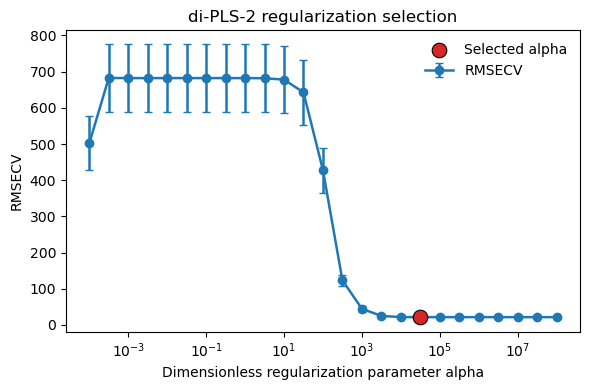

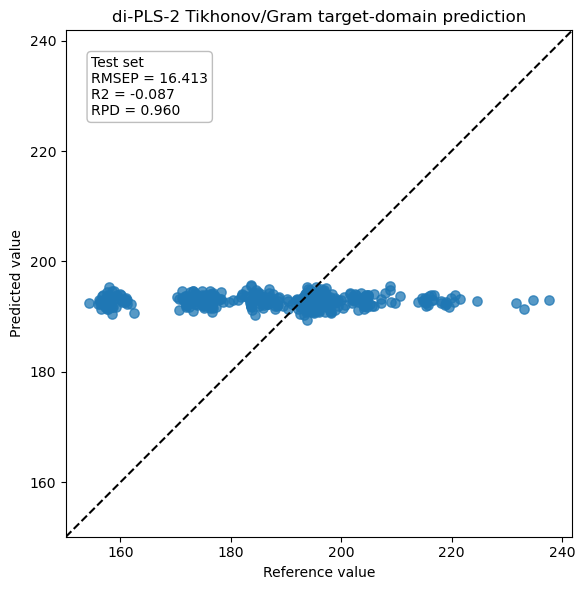

In [12]:
selected = results.iloc[0]
gamma_plot = gamma_cv_results.sort_values("alpha")

plt.figure(figsize=(6, 4))
plt.errorbar(
    gamma_plot["alpha"], gamma_plot["rmsecv"], yerr=gamma_plot["rmsecv_std"],
    fmt="o-", capsize=3, linewidth=1.8, markersize=6, label="RMSECV"
)
plt.scatter(
    [selected["selected_alpha"]], [selected["rmsecv"]],
    s=110, color="tab:red", edgecolor="black", linewidth=0.8,
    zorder=5, label="Selected alpha"
)
plt.xscale("log")
plt.xlabel("Dimensionless regularization parameter alpha")
plt.ylabel("RMSECV")
plt.title("di-PLS-2 regularization selection")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_tgt_test, y_target_pred, s=45, alpha=0.75)
ax = plt.gca()
metric_text = (
    "Test set\n"
    f"RMSEP = {selected['target_rmsep']:.3f}\n"
    f"R2 = {selected['target_r2']:.3f}\n"
    f"RPD = {selected['target_rpd']:.3f}"
)
ax.text(
    0.05, 0.95, metric_text,
    transform=ax.transAxes,
    va="top", ha="left",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.85},
    fontsize=10,
)
axis_min = float(min(y_tgt_test.min(), y_target_pred.min()))
axis_max = float(max(y_tgt_test.max(), y_target_pred.max()))
margin = 0.05 * (axis_max - axis_min)
axis_min -= margin
axis_max += margin
plt.plot([axis_min, axis_max], [axis_min, axis_max], "k--", linewidth=1.5)
plt.xlabel("Reference value")
plt.ylabel("Predicted value")
plt.title("di-PLS-2 Tikhonov/Gram target-domain prediction")
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()